# Multi-Asset Diagnostics (SP500, BTC, 10Y Yield)

This notebook analyzes three series over a trailing 5-year window ending 2026-03-14. Each series is evaluated in level and first-difference form, with compact diagnostics (series, ACF, PACF, Ljung–Box).

In [10]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.decomposition import PCA

from IPython.display import display, HTML

# Styling helper

def set_tableau_style():
    tableau_colors = [
        "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
        "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
        "#9C755F", "#BAB0AC"
    ]

    mpl.rcParams.update({
        "axes.prop_cycle": mpl.cycler(color=tableau_colors),
        "figure.facecolor": "white",
        "figure.figsize": (10, 6),
        "axes.facecolor": "white",
        "axes.edgecolor": "#CCCCCC",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.titlesize": 16,
        "axes.titleweight": "semibold",
        "axes.labelsize": 12,
        "grid.color": "#E6E6E6",
        "grid.linestyle": "-",
        "grid.linewidth": 1.0,
        "xtick.color": "#555555",
        "ytick.color": "#555555",
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.5,
        "lines.markersize": 6,
        "font.family": "sans-serif",
        "font.size": 12,
        "legend.frameon": False,
        "legend.fontsize": 11
    })

set_tableau_style()


In [2]:
# Diagnostic helpers (series plot, ACF/PACF, Ljung–Box)
def acf_pacf_summary(series, nlags=10, box_lags=10):
    series = series.dropna()
    acf_vals = acf(series, nlags=nlags, fft=False)
    pacf_vals = pacf(series, nlags=nlags)
    lb = acorr_ljungbox(series, lags=list(range(1, box_lags + 1)), return_df=True)
    return {
        'ACF': acf_vals[1:],  # lags 1 to nlags
        'PACF': pacf_vals[1:],
        'Ljung-Box p': lb['lb_pvalue'].values
    }


def plot_series_diagnostics(series, title, nlags=20, box_lag=10):
    series = series.dropna()
    # Use a wide but short layout; titles are scaled down to match other examples
    fig, axes = plt.subplots(2, 2, figsize=(12, 4))

    # Time series
    axes[0, 0].plot(series.index, series, linewidth=1)
    axes[0, 0].set_title(f"{title} - Series", fontsize=10)
    axes[0, 0].set_ylabel(series.name)

    # ACF
    plot_acf(series, lags=nlags, ax=axes[0, 1], alpha=0.05)
    axes[0, 1].set_title(f"{title} - ACF", fontsize=10)

    # PACF
    plot_pacf(series, lags=nlags, ax=axes[1, 0], alpha=0.05, method='ywm')
    axes[1, 0].set_title(f"{title} - PACF", fontsize=10)

    # Ljung-Box p-values (plotted as a bar chart)
    lb = acorr_ljungbox(series, lags=list(range(1, box_lag + 1)), return_df=True)
    pvals = lb['lb_pvalue'].values
    axes[1, 1].bar(range(1, box_lag + 1), pvals, color='#4E79A7', alpha=0.8)
    axes[1, 1].axhline(0.05, color='red', linestyle='--', linewidth=1)
    axes[1, 1].set_title(f"{title} - Ljung-Box p-values", fontsize=10)
    axes[1, 1].set_xlabel('Lag')
    axes[1, 1].set_ylabel('p-value')
    axes[1, 1].set_ylim(0, 1)

    fig.tight_layout()
    plt.show()

In [3]:
# Load data and prepare the 5-year window
# Using the processed/cleaned files (deterministic columns) per the initial notebooks
btc_path = "../data/processed/bitcoin_close.csv"
sp500_path = "../data/processed/sp500_cleaned.csv"
fred_path = "../data/processed/treasury_dgs10.csv"

btc = pd.read_csv(btc_path, parse_dates=["date"])
btc = btc.set_index("date").sort_index()
# Deterministic column name used in reference notebook
btc_series = btc["btc_close"]

sp500 = pd.read_csv(sp500_path, parse_dates=["date"])
sp500 = sp500.set_index("date").sort_index()
sp500_series = sp500["sp500"]

fred = pd.read_csv(fred_path, parse_dates=["date"])
fred = fred.set_index("date").sort_index()
dgs10_series = fred["dgs10"]

assets = pd.concat([btc_series, sp500_series, dgs10_series], axis=1, join="inner")
assets.columns = ["BTC", "SP500", "DGS10"]
assets = assets.dropna()

end_date = pd.Timestamp("2026-03-14")
start_date = end_date - pd.DateOffset(years=5)
assets = assets.loc[start_date:end_date].dropna()

print("Assets data shape:", assets.shape)
print("Date range:", assets.index.min(), "to", assets.index.max())
print("Columns:", list(assets.columns))

Assets data shape: (1229, 3)
Date range: 2021-03-15 00:00:00 to 2026-02-17 00:00:00
Columns: ['BTC', 'SP500', 'DGS10']


# Section 1: SP500 Diagnostics (Level + Difference)

We analyze the S&P 500 series on both levels and first differences. The plots show the time series, ACF, PACF, and Ljung-Box p-values (Box test) in a compact 2x2 layout.

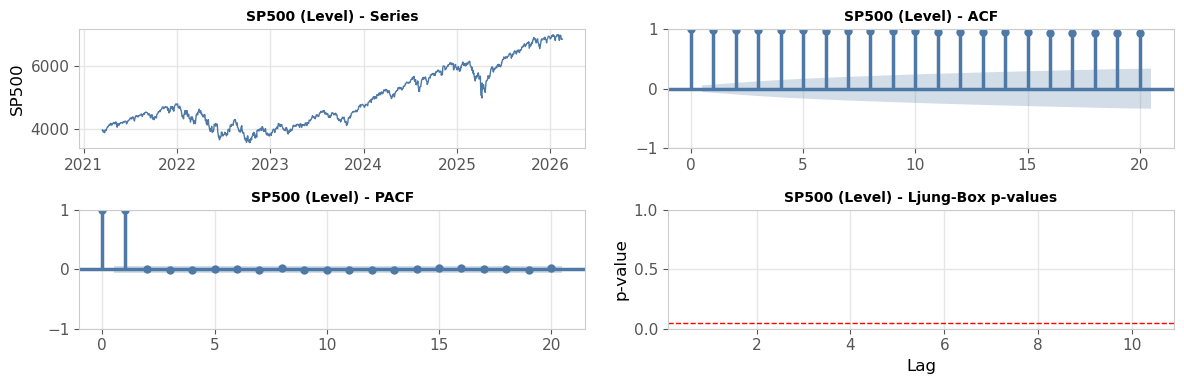

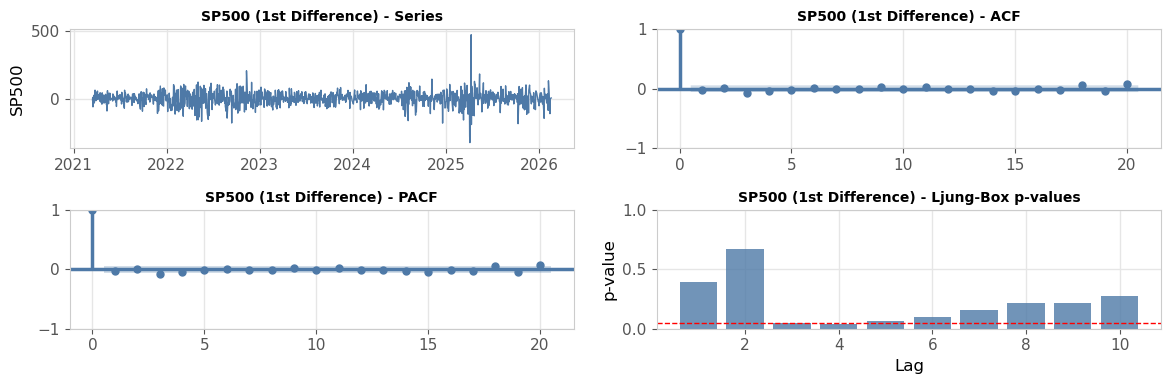

In [4]:
sp500_level = assets['SP500']
sp500_diff = sp500_level.diff().dropna()

plot_series_diagnostics(sp500_level, 'SP500 (Level)')
plot_series_diagnostics(sp500_diff, 'SP500 (1st Difference)')


# Section 2: Bitcoin Diagnostics (Level + Difference)

We perform the same diagnostics for Bitcoin.

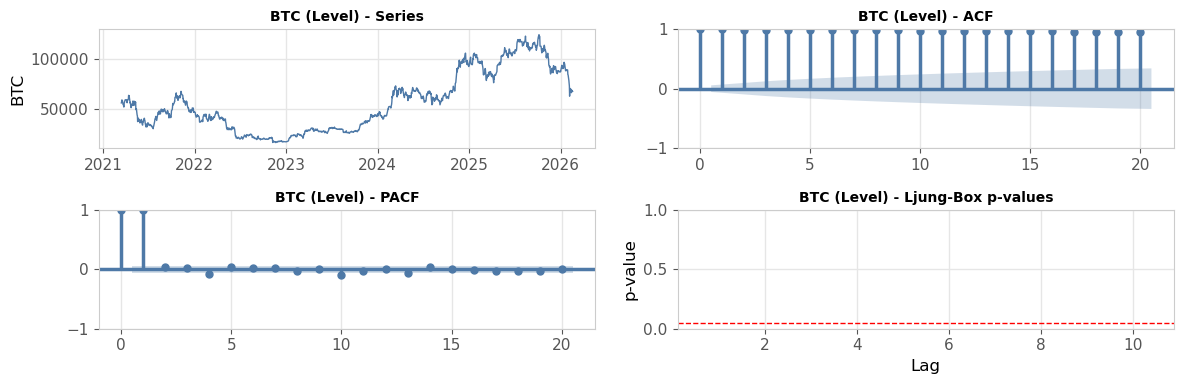

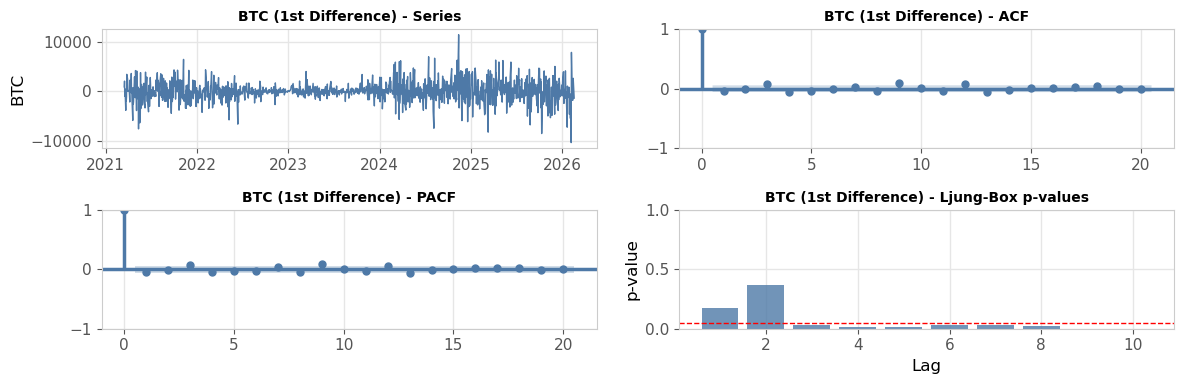

In [5]:
btc_level = assets['BTC']
btc_diff = btc_level.diff().dropna()

plot_series_diagnostics(btc_level, 'BTC (Level)')
plot_series_diagnostics(btc_diff, 'BTC (1st Difference)')


# Section 3: Yield Diagnostics (Level + Difference)

We now perform the same diagnostic plots for the 10Y Treasury yield.

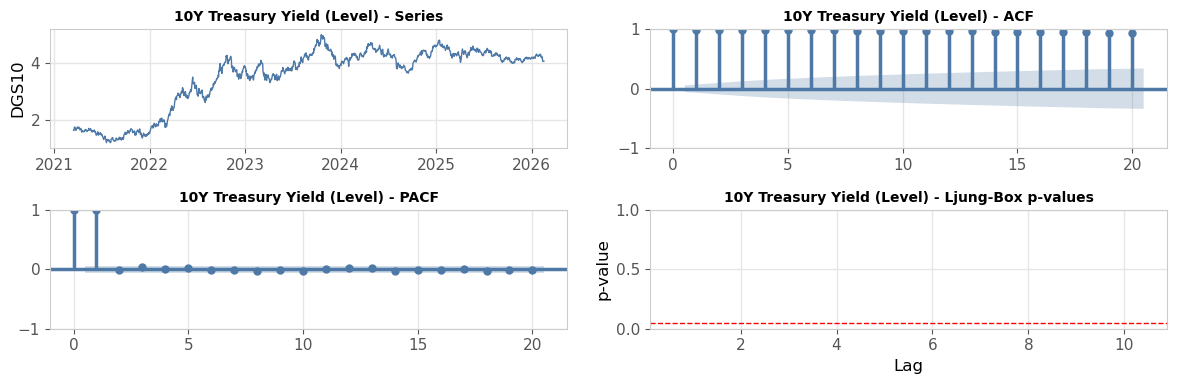

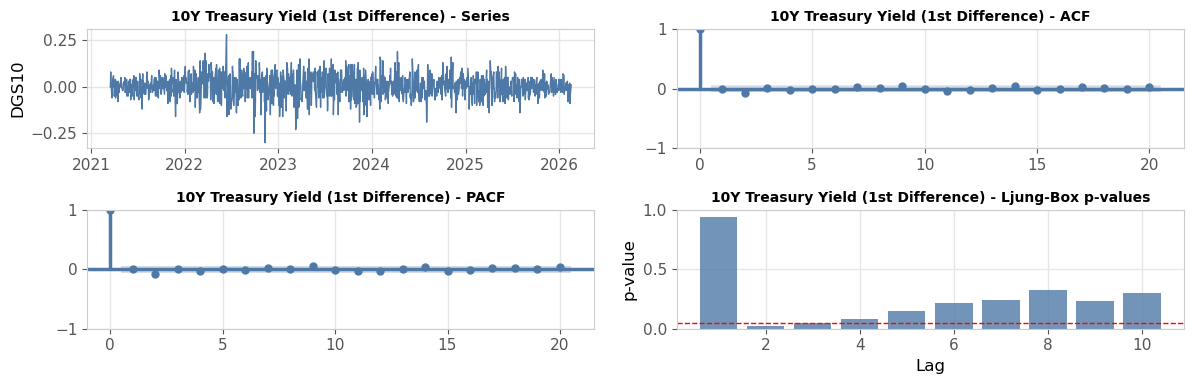

In [6]:
dgs10_level = assets['DGS10']
dgs10_diff = dgs10_level.diff().dropna()

plot_series_diagnostics(dgs10_level, '10Y Treasury Yield (Level)')
plot_series_diagnostics(dgs10_diff, '10Y Treasury Yield (1st Difference)')


# Section 4: Yield Curve PCA (Differenced Yield Changes)

We now perform PCA only on the yield curve series (multiple maturities) using the differenced yields, similar to the `YIELD_PCA` notebook. This section focuses on the first two principal components and provides diagnostic plots for each.

Yield curve data shape: (1232, 11)
Differenced yield data shape: (1231, 11)
Eigenvalues:
PC1: 0.027900
PC2: 0.004072
PC3: 0.003765
PC4: 0.001431
PC5: 0.000560
PC6: 0.000254
PC7: 0.000214
PC8: 0.000118
PC9: 0.000054
PC10: 0.000048
PC11: 0.000032

Proportion of variance explained:
PC1: 0.7256
PC2: 0.1059
PC3: 0.0979
PC4: 0.0372
PC5: 0.0146
PC6: 0.0066
PC7: 0.0056
PC8: 0.0031
PC9: 0.0014
PC10: 0.0012
PC11: 0.0008

Cumulative variance explained (%):
First 1 PCs: 72.6%
First 2 PCs: 83.2%
First 3 PCs: 92.9%
First 4 PCs: 96.7%
First 5 PCs: 98.1%
First 6 PCs: 98.8%
First 7 PCs: 99.3%
First 8 PCs: 99.7%
First 9 PCs: 99.8%
First 10 PCs: 99.9%
First 11 PCs: 100.0%


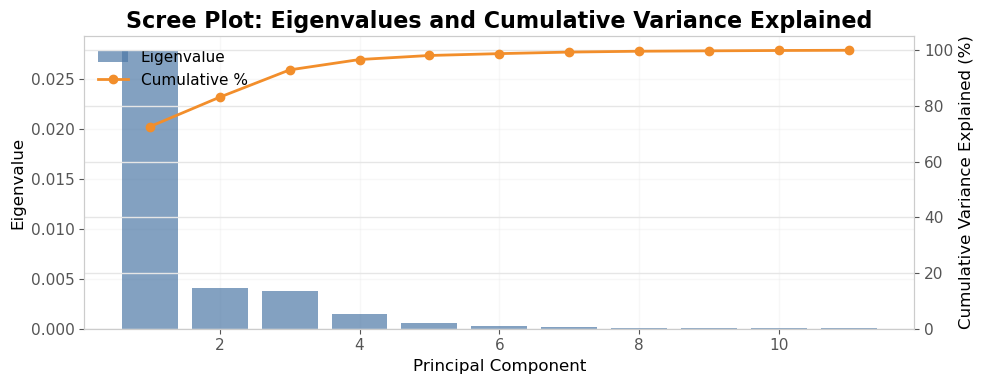

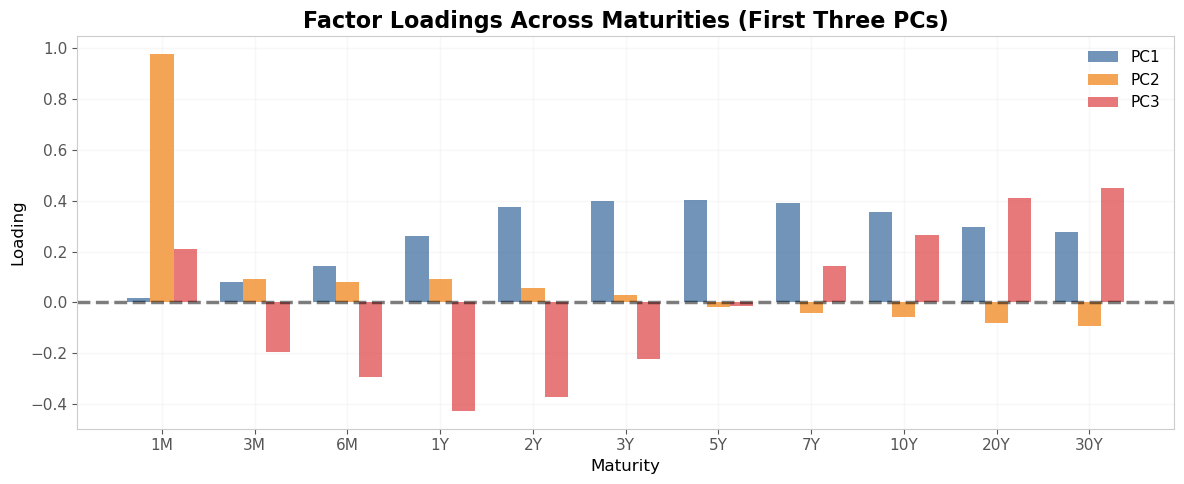

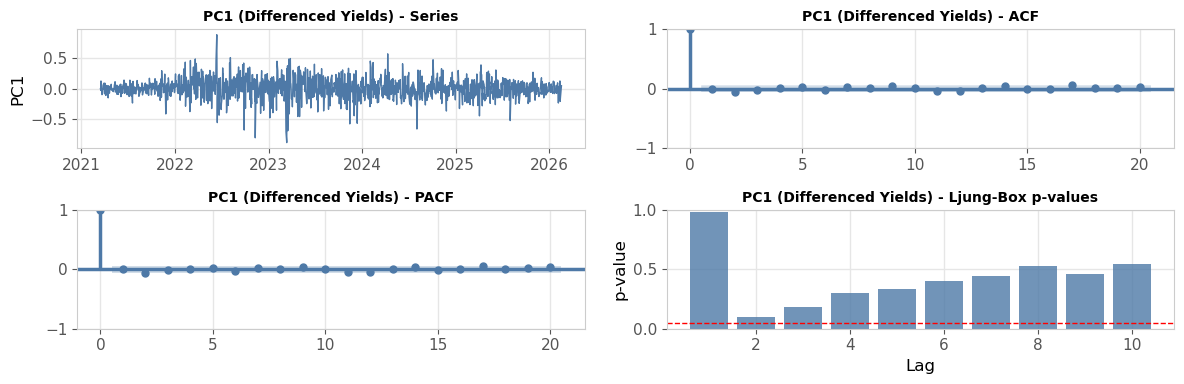

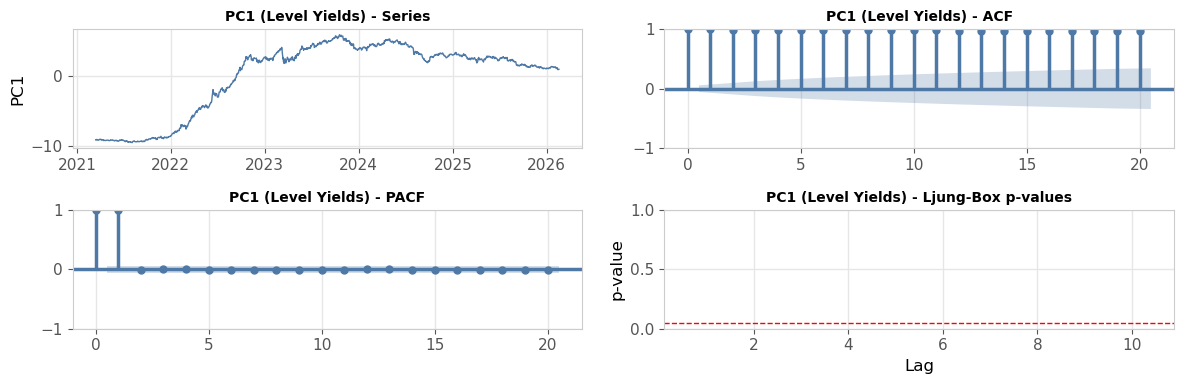

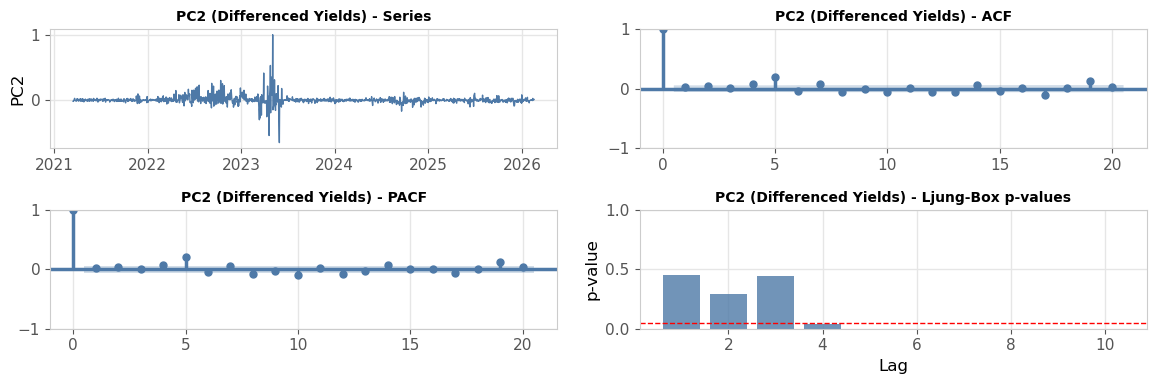

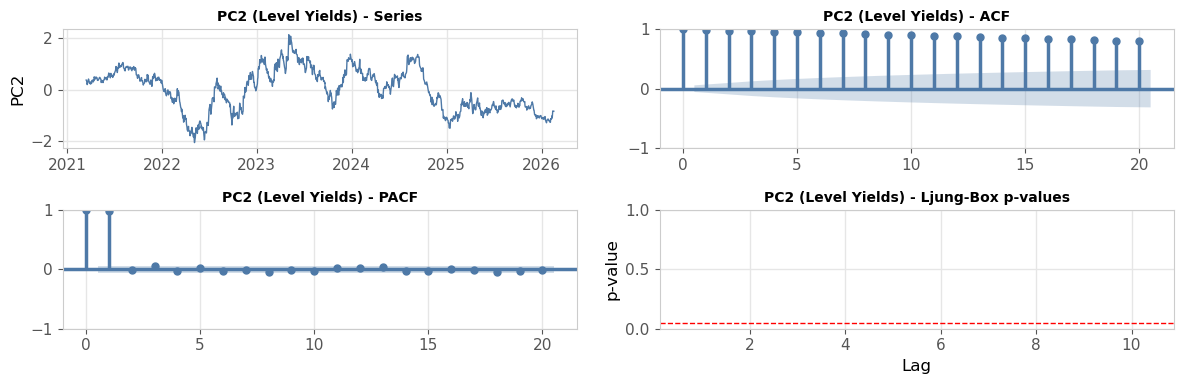

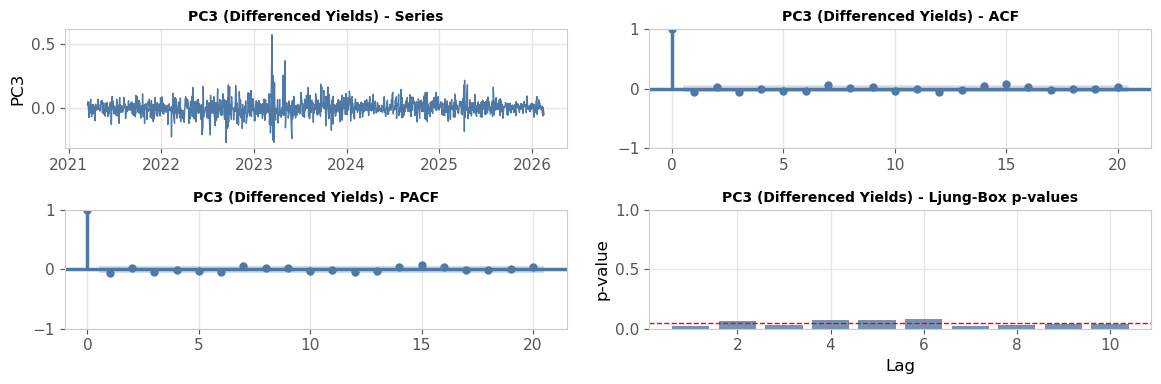

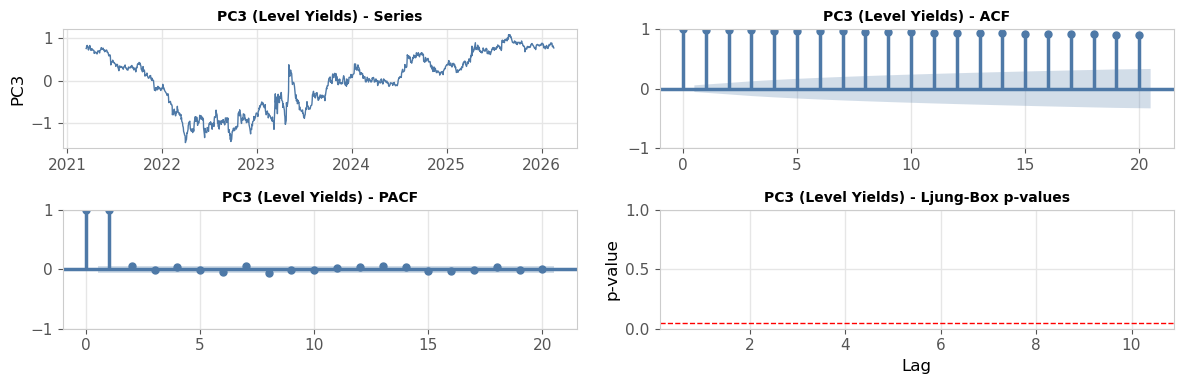

In [7]:
# Load the full yield curve (multiple maturities) from the raw FRED file
fred_path = "../data/raw/FRED.csv"
yields = pd.read_csv(fred_path, parse_dates=["observation_date"])

maturity_cols = {
    'DGS1MO': '1M',
    'DGS3MO': '3M',
    'DGS6MO': '6M',
    'DGS1': '1Y',
    'DGS2': '2Y',
    'DGS3': '3Y',
    'DGS5': '5Y',
    'DGS7': '7Y',
    'DGS10': '10Y',
    'DGS20': '20Y',
    'DGS30': '30Y'
}

yields = yields[['observation_date'] + list(maturity_cols.keys())]
yields = yields.rename(columns={'observation_date': 'date', **maturity_cols})
yields = yields.set_index('date').sort_index()

# Restrict to the same 5-year window as the rest of the notebook
yields = yields.loc[start_date:end_date]

for col in maturity_cols.values():
    yields[col] = pd.to_numeric(yields[col], errors='coerce')

yields = yields.dropna()

yields_diff = yields.diff().dropna()

print("Yield curve data shape:", yields.shape)
print("Differenced yield data shape:", yields_diff.shape)


def plot_pc_diagnostics(pc_series, title, nlags=40):
    """Plot time series, ACF, and PACF for a principal component."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))

    axes[0].plot(pc_series.index, pc_series, linewidth=1)
    axes[0].set_title(f"{title} - Series", fontsize=10)
    axes[0].set_ylabel('Score')
    axes[0].grid(True, alpha=0.3)

    plot_acf(pc_series.dropna(), lags=nlags, ax=axes[1], alpha=0.05)
    axes[1].set_title(f"{title} - ACF", fontsize=10)

    plot_pacf(pc_series.dropna(), lags=nlags, ax=axes[2], alpha=0.05, method='ywm')
    axes[2].set_title(f"{title} - PACF", fontsize=10)

    fig.tight_layout()
    plt.show()


# Run PCA on differenced yields only
pca = PCA()
pca.fit(yields_diff)

pc_scores_diff = pd.DataFrame(pca.transform(yields_diff), index=yields_diff.index, columns=[f'PC{i+1}' for i in range(yields_diff.shape[1])])

eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_

# Also compute PCA on yield levels so we can compare PC1 diagnostics on levels vs differences
pca_level = PCA()
pca_level.fit(yields)
pc_scores_level = pd.DataFrame(pca_level.transform(yields), index=yields.index, columns=[f'PC{i+1}' for i in range(yields.shape[1])])

cum_var_pct = np.cumsum(explained_variance_ratio) * 100

print("Eigenvalues:")
for i, ev in enumerate(eigenvalues, 1):
    print(f"PC{i}: {ev:.6f}")

print("\nProportion of variance explained:")
for i, ratio in enumerate(explained_variance_ratio, 1):
    print(f"PC{i}: {ratio:.4f}")

print("\nCumulative variance explained (%):")
for i, cum in enumerate(cum_var_pct, 1):
    print(f"First {i} PCs: {cum:.1f}%")

# Scree plot: eigenvalues + cumulative explained variance (percent)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(range(1, len(eigenvalues) + 1), eigenvalues, color='#4E79A7', alpha=0.7, label='Eigenvalue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Scree Plot: Eigenvalues and Cumulative Variance Explained')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(range(1, len(eigenvalues) + 1), cum_var_pct, color='#F28E2B', marker='o', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_ylim(0, 105)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Loadings plot (first 3 PCs)
loadings = pd.DataFrame(pca.components_.T, index=yields_diff.columns, columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])])
loadings_subset = loadings[['PC1', 'PC2', 'PC3']]

maturity_order = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
loadings_subset = loadings_subset.reindex(maturity_order)

fig, ax = plt.subplots(figsize=(12, 5))
bar_width = 0.25
x = np.arange(len(maturity_order))
ax.bar(x - bar_width, loadings_subset['PC1'], width=bar_width, label='PC1', alpha=0.8)
ax.bar(x, loadings_subset['PC2'], width=bar_width, label='PC2', alpha=0.8)
ax.bar(x + bar_width, loadings_subset['PC3'], width=bar_width, label='PC3', alpha=0.8)
ax.set_xlabel('Maturity')
ax.set_ylabel('Loading')
ax.set_title('Factor Loadings Across Maturities (First Three PCs)')
ax.set_xticks(x)
ax.set_xticklabels(maturity_order)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Diagnostics for PC1, PC2, PC3 on differenced yields and level yields (24 total diagnostic plots)

# PC1
plot_series_diagnostics(pc_scores_diff['PC1'], 'PC1 (Differenced Yields)')
plot_series_diagnostics(pc_scores_level['PC1'], 'PC1 (Level Yields)')

# PC2
plot_series_diagnostics(pc_scores_diff['PC2'], 'PC2 (Differenced Yields)')
plot_series_diagnostics(pc_scores_level['PC2'], 'PC2 (Level Yields)')

# PC3
plot_series_diagnostics(pc_scores_diff['PC3'], 'PC3 (Differenced Yields)')
plot_series_diagnostics(pc_scores_level['PC3'], 'PC3 (Level Yields)')


# Section 5: Aggregate Comparison Across Series

Compare all series side-by-side (level and differences) and summarize autocorrelation statistics.

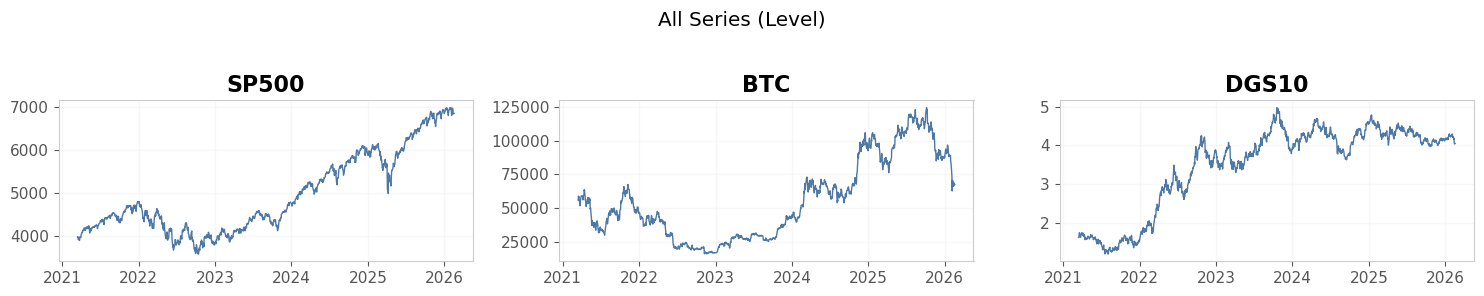

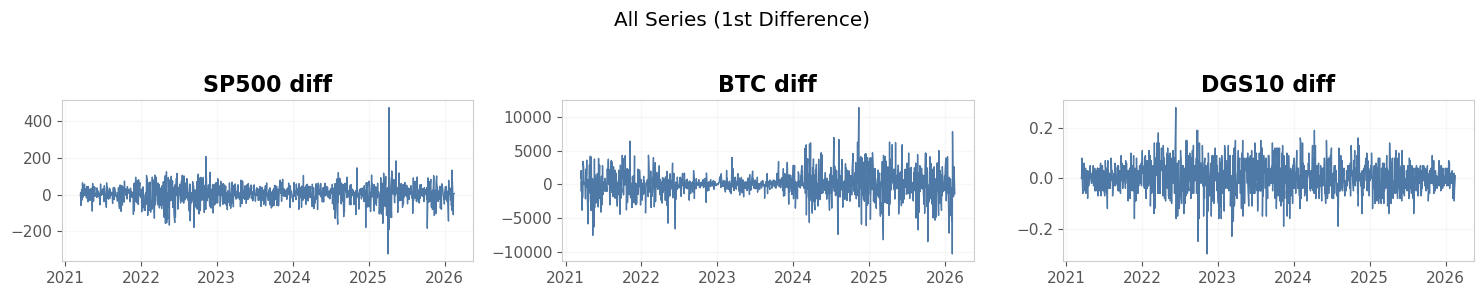

In [ ]:
# Side-by-side plots (level)
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharex=True)
for ax, col in zip(axes, ['SP500', 'BTC', 'DGS10']):
    ax.plot(assets.index, assets[col], linewidth=1)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
plt.suptitle('All Series (Level)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Side-by-side plots (difference)
diff_assets = assets.diff().dropna()
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharex=True)
for ax, col in zip(axes, ['SP500', 'BTC', 'DGS10']):
    ax.plot(diff_assets.index, diff_assets[col], linewidth=1)
    ax.set_title(f"{col} diff")
    ax.grid(True, alpha=0.3)
plt.suptitle('All Series (1st Difference)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Autocorrelation summary table (lags 1 to 5)
summary_rows = []
for label, series in [
    ('SP500 (level)', assets['SP500']),
    ('SP500 (diff)', diff_assets['SP500']),
    ('BTC (level)', assets['BTC']),
    ('BTC (diff)', diff_assets['BTC']),
    ('DGS10 (level)', assets['DGS10']),
    ('DGS10 (diff)', diff_assets['DGS10']),
]:
    stats = acf_pacf_summary(series, nlags=5, box_lags=5)
    row = {'Series': label}
    for i in range(5):
        row[f'ACF_{i+1}'] = stats['ACF'][i]
        row[f'PACF_{i+1}'] = stats['PACF'][i]
        row[f'Ljung_{i+1}'] = stats['Ljung-Box p'][i]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index('Series')

# Create multi-level columns
acf_cols = [('ACF', f'Lag {i+1}') for i in range(5)]
pacf_cols = [('PACF', f'Lag {i+1}') for i in range(5)]
ljung_cols = [('Ljung-Box p', f'Lag {i+1}') for i in range(5)]
multi_cols = pd.MultiIndex.from_tuples(acf_cols + pacf_cols + ljung_cols)
summary_df.columns = multi_cols

# Round to 2 decimals and apply heatmap styling
summary_df.style.format("{:.3f}").background_gradient(cmap='RdYlGn_r', axis=None).set_table_styles([
    {'selector': 'th, td', 'props': [('border', '1px solid black')]}
])
